# 08 — 2022 World Cup Backtest

Validate our model by simulating the **2022 Qatar World Cup** 10,000 times.

**Ground truth:** Argentina won. 32 teams, 8 groups, R16 → Final.

**What we check:**
1. Did Argentina have a high win probability?
2. Did the actual group qualifiers match our predicted qualifiers?
3. How far did each actual finalist rank in our predictions?

In [4]:
import numpy as np
import pandas as pd
import joblib, json, warnings
from pathlib import Path
from scipy.stats import poisson
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
warnings.filterwarnings('ignore')

PROCESSED_DIR = Path('../data/processed')
MODELS_DIR    = Path('../models')
print('Libraries loaded.')

Libraries loaded.


In [5]:
# Load model bundle
model_bundle = joblib.load(MODELS_DIR / 'best_model.pkl')
xgb_model = model_bundle['xgb']
rf_model  = model_bundle['rf']
W_XGB, W_RF, W_DC = model_bundle['w_xgb'], model_bundle['w_rf'], model_bundle['w_dc']

scaler    = joblib.load(MODELS_DIR / 'scaler.pkl')
le        = joblib.load(MODELS_DIR / 'label_encoder.pkl')

# DC ratings
dc_df = pd.read_csv(PROCESSED_DIR / 'dc_ratings.csv')
attack_params  = dict(zip(dc_df['team'], dc_df['attack']))
defense_params = dict(zip(dc_df['team'], dc_df['defense']))
home_adv = float(dc_df['home_adv'].iloc[0]) if 'home_adv' in dc_df.columns else 0.287
rho      = float(dc_df['rho'].iloc[0]) if 'rho' in dc_df.columns else -0.0844

print(f'Model: XGB*{W_XGB} + RF*{W_RF} + DC*{W_DC}')
print(f'DC home_adv={home_adv:.3f}, rho={rho:.4f}, DC teams={len(attack_params)}')

Model: XGB*4 + RF*1 + DC*5
DC home_adv=0.287, rho=-0.0844, DC teams=317


In [6]:
# Load 2022 WC ground truth + historical data
with open(PROCESSED_DIR / 'wc2022_ground_truth.json') as f:
    gt = json.load(f)

GROUPS_2022    = gt['groups']
ACTUAL_R16     = gt['actual_r16']
ACTUAL_WINNER  = gt['actual_winner']

matches = pd.read_csv(PROCESSED_DIR / 'matches_clean.csv')
matches['date'] = pd.to_datetime(matches['date'])
PRE_WC = matches[matches['date'] < '2022-11-20'].copy()

elo_df = pd.read_csv(PROCESSED_DIR / 'final_elos.csv')
elos_2022 = dict(zip(elo_df['team'], elo_df['final_elo']))

conf_df = pd.read_csv(PROCESSED_DIR / 'team_confederations.csv')
confs   = dict(zip(conf_df['team'], conf_df['confederation']))

print(f'Pre-tournament matches: {len(PRE_WC):,}')
print(f'Actual winner: {ACTUAL_WINNER}')
print('Groups:', list(GROUPS_2022.keys()))

Pre-tournament matches: 56,277
Actual winner: Argentina
Groups: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']


In [7]:
# Form + H2H helpers (identical logic to notebook 07, cutoff = 2022-11-20)
CUTOFF = pd.Timestamp('2022-11-20')

def get_form(team, n):
    df = PRE_WC[(PRE_WC['home_team']==team)|(PRE_WC['away_team']==team)].tail(n)
    if len(df)==0: return 0.0,1.0,1.0,0.0,0
    wins,pts,gf,ga = 0,0,0,0
    for _,r in df.iterrows():
        if r['home_team']==team:
            gf+=r['home_score']; ga+=r['away_score']
            if r['outcome']=='home_win': wins+=1; pts+=3
            elif r['outcome']=='draw': pts+=1
        else:
            gf+=r['away_score']; ga+=r['home_score']
            if r['outcome']=='away_win': wins+=1; pts+=3
            elif r['outcome']=='draw': pts+=1
    n_=len(df)
    return wins/n_,gf/n_,ga/n_,pts/n_,n_

def get_h2h(home, away):
    df = PRE_WC[
        ((PRE_WC['home_team']==home)&(PRE_WC['away_team']==away))|
        ((PRE_WC['home_team']==away)&(PRE_WC['away_team']==home))
    ]
    if len(df)==0: return 0.5,1.0,1.0,0,0.5
    hw,hgf,hga=0,0,0
    for _,r in df.iterrows():
        if r['home_team']==home:
            hgf+=r['home_score']; hga+=r['away_score']
            if r['outcome']=='home_win': hw+=1
        else:
            hgf+=r['away_score']; hga+=r['home_score']
            if r['outcome']=='away_win': hw+=1
    n_=len(df)
    recent=df.tail(5)
    rw=sum(1 for _,r in recent.iterrows()
           if (r['home_team']==home and r['outcome']=='home_win') or
              (r['away_team']==home and r['outcome']=='away_win'))
    return hw/n_,hgf/n_,hga/n_,n_,rw/len(recent)

def conf_onehot(team):
    ALL_CONFS=['UEFA','CAF','AFC','CONCACAF','CONMEBOL','OFC','UNKNOWN']
    c=confs.get(team,'UNKNOWN')
    return [1 if c==x else 0 for x in ALL_CONFS]

print('Form helpers defined.')

Form helpers defined.


In [8]:
from scipy.stats import poisson as sppoisson

def dc_prob(lam, mu, rho_val):
    def tau(x,y,l,m,r):
        if x==0 and y==0: return 1-l*m*r
        elif x==0 and y==1: return 1+l*r
        elif x==1 and y==0: return 1+m*r
        elif x==1 and y==1: return 1-r
        return 1.0
    hw=dw=aw=0.0
    for i in range(8):
        for j in range(8):
            p=tau(i,j,lam,mu,rho_val)*sppoisson.pmf(i,lam)*sppoisson.pmf(j,mu)
            if i>j: hw+=p
            elif i==j: dw+=p
            else: aw+=p
    s=hw+dw+aw; return hw/s,dw/s,aw/s

def build_features_2022(home, away, neutral=True):
    h_elo=elos_2022.get(home,1500); a_elo=elos_2022.get(away,1500)
    elo_diff=h_elo-a_elo
    hw5,hs5,hc5,hp5,hm5   = get_form(home,5)
    hw10,hs10,hc10,hp10,hm10 = get_form(home,10)
    aw5,as5,ac5,ap5,am5   = get_form(away,5)
    aw10,as10,ac10,ap10,am10 = get_form(away,10)
    h2h_wr,h2h_gs,h2h_gc,h2h_n,h2h_r = get_h2h(home,away)
    h_conf=conf_onehot(home); a_conf=conf_onehot(away)
    same_conf=1 if confs.get(home,'?')==confs.get(away,'?') else 0
    base=[h_elo,a_elo,elo_diff,
          hw5,hs5,hc5,hp5,hm5,hw10,hs10,hc10,hp10,hm10,
          aw5,as5,ac5,ap5,am5,aw10,as10,ac10,ap10,am10,
          h2h_wr,h2h_gs,h2h_gc,h2h_n,h2h_r,
          1 if neutral else 0, 1.0]+h_conf+a_conf+[same_conf]
    elo_diff_sq=elo_diff**2*np.sign(elo_diff)
    h_mom=hw5-hw10; a_mom=aw5-aw10
    h_gdf=hs5-hc5; a_gdf=as5-ac5; net_gd=h_gdf-a_gdf
    h2h_conf=h2h_r*(h2h_n/(h2h_n+5))
    eng=base+[elo_diff_sq,h_mom,a_mom,h_gdf,a_gdf,net_gd,h2h_conf]
    ha=attack_params.get(home,0.0); hd=defense_params.get(home,0.0)
    aa=attack_params.get(away,0.0); ad=defense_params.get(away,0.0)
    dc_lam=max(np.exp(ha+ad),0.01); dc_mu=max(np.exp(aa+hd),0.01)
    dc_hw,dc_dr,dc_aw=dc_prob(dc_lam,dc_mu,rho)
    dc_feats=[dc_hw,dc_dr,dc_aw,dc_lam,dc_mu,dc_lam+dc_mu,dc_lam-dc_mu]
    return np.array(eng+dc_feats,dtype=np.float64)

def predict_match_2022(home, away, neutral=True):
    feat=build_features_2022(home,away,neutral).reshape(1,-1)
    feat_s=scaler.transform(feat)
    xgb_p=xgb_model.predict_proba(feat_s)[0]
    rf_p=rf_model.predict_proba(feat_s)[0]
    feat_arr=build_features_2022(home,away,neutral)
    dc_hw,dc_dr,dc_aw=feat_arr[-7],feat_arr[-6],feat_arr[-5]
    dc_p=np.array([dc_aw,dc_dr,dc_hw])
    blended=(W_XGB*xgb_p+W_RF*rf_p+W_DC*dc_p)/(W_XGB+W_RF+W_DC)
    return blended[2],blended[1],blended[0]  # p_home,p_draw,p_away

ph,pd_,pa=predict_match_2022('Argentina','France',neutral=True)
print(f'Sanity — Argentina vs France: home={ph:.3f} draw={pd_:.3f} away={pa:.3f}')
ph,pd_,pa=predict_match_2022('Brazil','Serbia',neutral=True)
print(f'Sanity — Brazil vs Serbia:    home={ph:.3f} draw={pd_:.3f} away={pa:.3f}')

Sanity — Argentina vs France: home=0.483 draw=0.294 away=0.223
Sanity — Brazil vs Serbia:    home=0.677 draw=0.224 away=0.099


In [9]:
%%time
# Build probability cache for all 32x31 matchups
all_2022_teams = [t for grp in GROUPS_2022.values() for t in grp]
print(f'Teams: {len(all_2022_teams)}')
_cache_2022 = {}
for home in all_2022_teams:
    for away in all_2022_teams:
        if home != away:
            _cache_2022[(home,away)] = predict_match_2022(home,away,neutral=True)

_orig_pm2022 = predict_match_2022
def predict_match_2022(home, away, neutral=True):
    if (home,away) in _cache_2022: return _cache_2022[(home,away)]
    return _orig_pm2022(home,away,neutral)

ph,pd_,pa = predict_match_2022('Argentina','France')
print(f'Cache active ({len(_cache_2022)} matchups). Argentina vs France: home={ph:.3f} draw={pd_:.3f} away={pa:.3f}')

Teams: 32
Cache active (992 matchups). Argentina vs France: home=0.483 draw=0.294 away=0.223
CPU times: total: 20min 25s
Wall time: 12min 54s


In [10]:
def simulate_ko_2022(t1, t2):
    ph,pd_,pa = predict_match_2022(t1,t2,neutral=True)
    result = np.random.choice(['home','draw','away'],p=[ph,pd_,pa])
    if result=='home': return t1
    elif result=='away': return t2
    else:
        p_home_et = ph/(ph+pa)
        return t1 if np.random.random()<p_home_et else t2

def simulate_group_2022(group_teams):
    stats={t:{'pts':0,'gd':0,'gf':0} for t in group_teams}
    pairs=[(group_teams[i],group_teams[j])
           for i in range(len(group_teams)) for j in range(i+1,len(group_teams))]
    for h,a in pairs:
        ph,pd_,pa=predict_match_2022(h,a,neutral=True)
        result=np.random.choice(['home','draw','away'],p=[ph,pd_,pa])
        hg=np.random.poisson(max(np.exp(attack_params.get(h,0)+defense_params.get(a,0)),0.3))
        ag=np.random.poisson(max(np.exp(attack_params.get(a,0)+defense_params.get(h,0)),0.3))
        if result=='home' and hg<=ag: hg=ag+1
        elif result=='away' and ag<=hg: ag=hg+1
        elif result=='draw': ag=hg
        if result=='home': stats[h]['pts']+=3
        elif result=='away': stats[a]['pts']+=3
        else: stats[h]['pts']+=1; stats[a]['pts']+=1
        stats[h]['gd']+=hg-ag; stats[a]['gd']+=ag-hg
        stats[h]['gf']+=hg; stats[a]['gf']+=ag
    standing=sorted(stats.items(),key=lambda x:(-x[1]['pts'],-x[1]['gd'],-x[1]['gf']))
    return [s[0] for s in standing]

def simulate_tournament_2022():
    qualifiers={}
    for grp,teams in GROUPS_2022.items():
        standing=simulate_group_2022(teams)
        qualifiers[grp]=(standing[0],standing[1])
    # 2022 R16 bracket
    r16=[
        (qualifiers['A'][0],qualifiers['B'][1]),
        (qualifiers['C'][0],qualifiers['D'][1]),
        (qualifiers['B'][0],qualifiers['A'][1]),
        (qualifiers['D'][0],qualifiers['C'][1]),
        (qualifiers['E'][0],qualifiers['F'][1]),
        (qualifiers['G'][0],qualifiers['H'][1]),
        (qualifiers['F'][0],qualifiers['E'][1]),
        (qualifiers['H'][0],qualifiers['G'][1]),
    ]
    def play_round(matchups): return [simulate_ko_2022(t1,t2) for t1,t2 in matchups]
    r16w=play_round(r16)
    qfw=play_round([(r16w[0],r16w[1]),(r16w[2],r16w[3]),(r16w[4],r16w[5]),(r16w[6],r16w[7])])
    sfw=play_round([(qfw[0],qfw[1]),(qfw[2],qfw[3])])
    champ=simulate_ko_2022(sfw[0],sfw[1])
    return champ, qualifiers

print('2022 simulators defined.')

2022 simulators defined.


In [11]:
%%time
N_SIMS = 10_000
champion_counts_2022 = {}
group_qual_counts = {grp:{} for grp in GROUPS_2022}

for _ in tqdm(range(N_SIMS), desc='Simulating 2022 WC'):
    champ, qualifiers = simulate_tournament_2022()
    champion_counts_2022[champ] = champion_counts_2022.get(champ,0)+1
    for grp,(w,r) in qualifiers.items():
        for team in [w,r]:
            group_qual_counts[grp][team]=group_qual_counts[grp].get(team,0)+1

win_probs_2022=pd.DataFrame([
    {'team':t,'wins':c,'win_pct':round(c/N_SIMS*100,2)}
    for t,c in champion_counts_2022.items()
]).sort_values('win_pct',ascending=False).reset_index(drop=True)

print(f'\nSimulated {N_SIMS:,} tournaments')
print(f'Argentina win%: {champion_counts_2022.get("Argentina",0)/N_SIMS*100:.2f}%')
print()
print('=== Predicted Win Probabilities ===')
print(win_probs_2022.head(20).to_string(index=False))

Simulating 2022 WC: 100%|██████████| 10000/10000 [00:32<00:00, 307.86it/s]


Simulated 10,000 tournaments
Argentina win%: 14.77%

=== Predicted Win Probabilities ===
         team  wins  win_pct
        Spain  2286    22.86
    Argentina  1477    14.77
       France   798     7.98
      Senegal   676     6.76
       Mexico   628     6.28
        Japan   627     6.27
    Australia   519     5.19
      England   517     5.17
      Morocco   453     4.53
       Brazil   317     3.17
  Netherlands   300     3.00
     Portugal   221     2.21
United States   190     1.90
      Germany   177     1.77
      Ecuador   142     1.42
  South Korea   115     1.15
      Denmark    93     0.93
         Iran    92     0.92
  Switzerland    90     0.90
      Croatia    74     0.74
CPU times: total: 31.3 s
Wall time: 32.5 s


In [12]:
# Group qualification accuracy
print('=== Group Qualification Accuracy ===\n')
correct_qualifiers=0; total_slots=0
for grp in sorted(GROUPS_2022.keys()):
    actual_w,actual_r = ACTUAL_R16[grp]
    actual_set={actual_w,actual_r}
    pred=group_qual_counts[grp]
    pred_top2=sorted(pred,key=pred.get,reverse=True)[:2]
    pred_set=set(pred_top2)
    overlap=len(actual_set & pred_set)
    correct_qualifiers+=overlap; total_slots+=2
    print(f'Group {grp}: Actual={actual_set}')
    for team in GROUPS_2022[grp]:
        pct=pred.get(team,0)/N_SIMS*100
        marker='OK' if team in actual_set else '  '
        print(f'  [{marker}] {team:20s} qualified {pct:.1f}%')
    print()
print(f'Correct qualifiers: {correct_qualifiers}/{total_slots} = {correct_qualifiers/total_slots*100:.1f}%')

=== Group Qualification Accuracy ===

Group A: Actual={'Netherlands', 'Senegal'}
  [  ] Qatar                qualified 25.3%
  [  ] Ecuador              qualified 51.0%
  [OK] Senegal              qualified 70.4%
  [OK] Netherlands          qualified 53.3%

Group B: Actual={'England', 'United States'}
  [OK] England              qualified 73.8%
  [  ] Iran                 qualified 54.6%
  [OK] United States        qualified 56.5%
  [  ] Wales                qualified 15.2%

Group C: Actual={'Argentina', 'Poland'}
  [OK] Argentina            qualified 85.4%
  [  ] Saudi Arabia         qualified 27.8%
  [  ] Mexico               qualified 75.9%
  [OK] Poland               qualified 10.9%

Group D: Actual={'Australia', 'France'}
  [OK] France               qualified 76.1%
  [OK] Australia            qualified 71.1%
  [  ] Denmark              qualified 39.9%
  [  ] Tunisia              qualified 12.8%

Group E: Actual={'Spain', 'Japan'}
  [OK] Spain                qualified 83.4%
  [  ] 

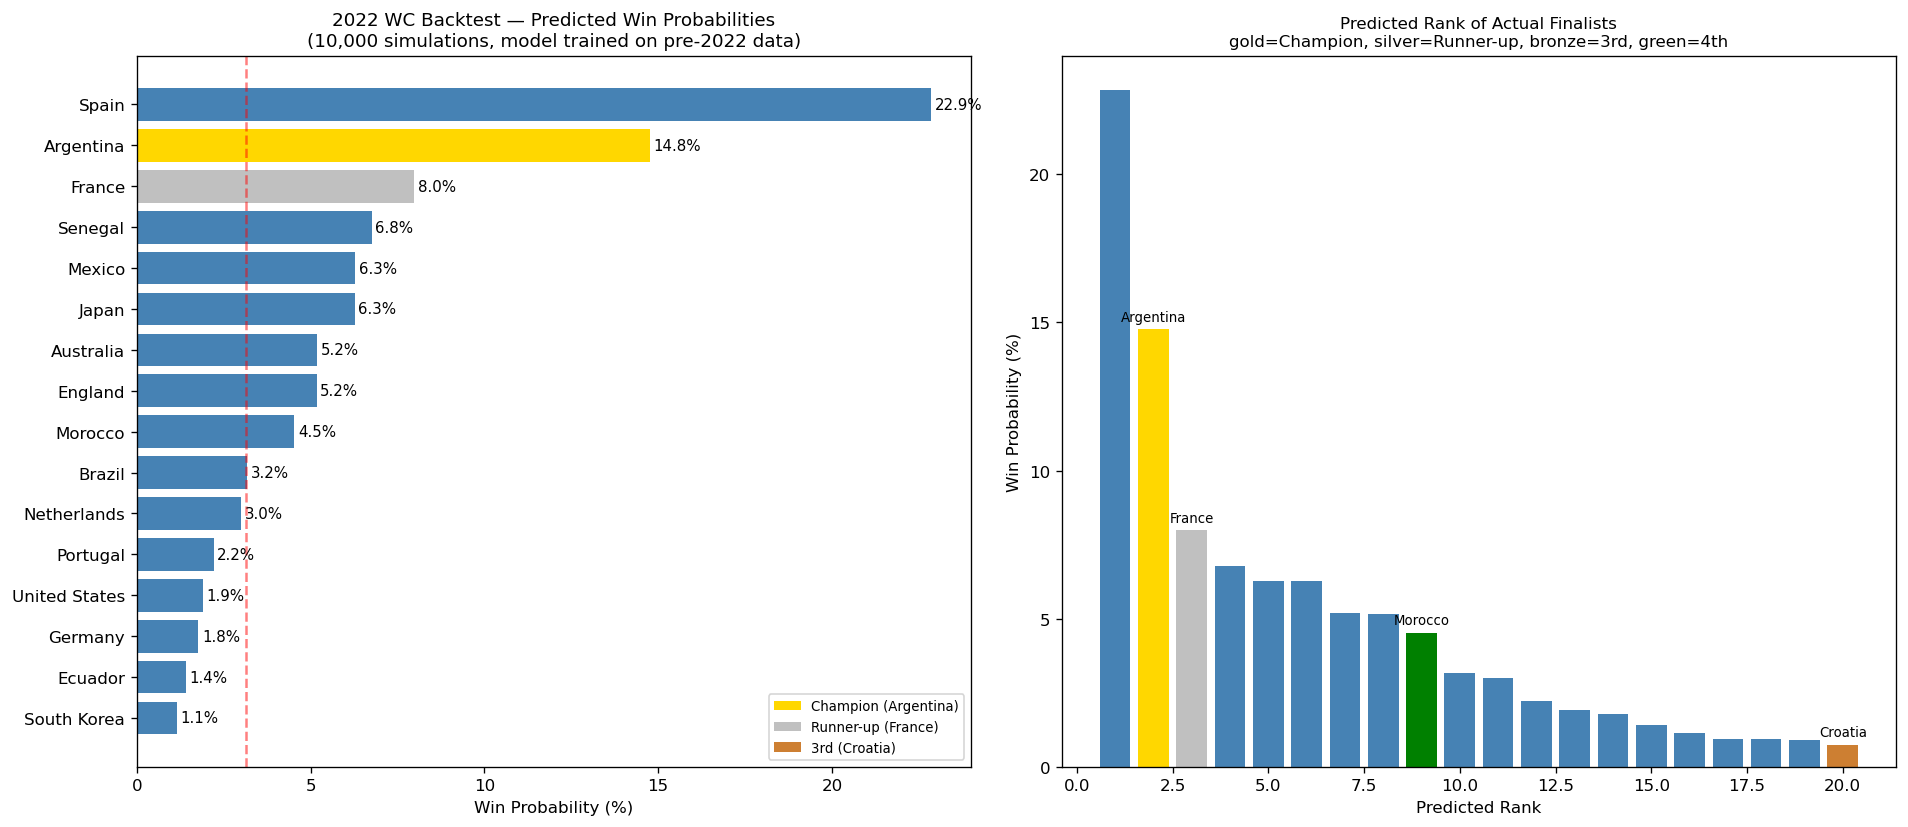

Chart saved.


In [13]:
fig,axes=plt.subplots(1,2,figsize=(16,7))

top16=win_probs_2022.head(16)
ax=axes[0]
colors=['gold' if t=='Argentina' else 'silver' if t=='France' else '#CD7F32' if t=='Croatia' else 'steelblue' for t in top16['team'][::-1]]
bars=ax.barh(top16['team'][::-1],top16['win_pct'][::-1],color=colors)
ax.set_xlabel('Win Probability (%)')
ax.set_title('2022 WC Backtest — Predicted Win Probabilities\n(10,000 simulations, model trained on pre-2022 data)',fontsize=11)
for bar,val in zip(bars,top16['win_pct'][::-1]):
    ax.text(bar.get_width()+0.1,bar.get_y()+bar.get_height()/2,f'{val:.1f}%',va='center',fontsize=9)
ax.axvline(x=100/32,color='red',linestyle='--',alpha=0.5,label='Random baseline (3.1%)')
ax.legend(fontsize=9)
from matplotlib.patches import Patch
legend_elements=[Patch(facecolor='gold',label='Champion (Argentina)'),
                 Patch(facecolor='silver',label='Runner-up (France)'),
                 Patch(facecolor='#CD7F32',label='3rd (Croatia)')]
ax.legend(handles=legend_elements,fontsize=8,loc='lower right')

ax2=axes[1]
rank_df=win_probs_2022.reset_index()
rank_df.columns=['rank','team','wins','win_pct']
rank_df['rank']+=1
actual_finishes={'Argentina':'Champion','France':'Runner-up','Croatia':'3rd','Morocco':'4th'}
bar_colors=['gold' if t=='Argentina' else 'silver' if t=='France' else '#CD7F32' if t=='Croatia' else 'green' if t=='Morocco' else 'steelblue' for t in rank_df['team'][:20]]
ax2.bar(rank_df['rank'][:20],rank_df['win_pct'][:20],color=bar_colors)
ax2.set_xlabel('Predicted Rank')
ax2.set_ylabel('Win Probability (%)')
ax2.set_title('Predicted Rank of Actual Finalists\ngold=Champion, silver=Runner-up, bronze=3rd, green=4th',fontsize=10)
for _,row in rank_df[rank_df['team'].isin(actual_finishes)].iterrows():
    ax2.annotate(row['team'],(row['rank'],row['win_pct']),
                 textcoords='offset points',xytext=(0,5),ha='center',fontsize=8)

plt.tight_layout()
plt.savefig('../data/processed/wc2022_backtest.png',dpi=150,bbox_inches='tight')
plt.show()
print('Chart saved.')

In [14]:
arg_pct=champion_counts_2022.get('Argentina',0)/N_SIMS*100
fra_pct=champion_counts_2022.get('France',0)/N_SIMS*100
arg_rank=win_probs_2022[win_probs_2022['team']=='Argentina'].index[0]+1
fra_rank=win_probs_2022[win_probs_2022['team']=='France'].index[0]+1

print('='*55)
print('BACKTEST SCORECARD')
print('='*55)
print(f'Actual champion:         Argentina')
print(f'Argentina predicted:     {arg_pct:.2f}%  (rank #{arg_rank})')
print(f'France predicted:        {fra_pct:.2f}%  (rank #{fra_rank})')
print(f'Group qual accuracy:     {correct_qualifiers}/{total_slots} = {correct_qualifiers/total_slots*100:.1f}%')
print(f'Teams that won sim:      {len(win_probs_2022)}')
print()
print('Actual finalists vs predicted rank:')
for team,finish in [('Argentina','Champion'),('France','Runner-up'),('Croatia','3rd'),('Morocco','4th')]:
    r=win_probs_2022[win_probs_2022['team']==team]
    if len(r):
        pct=r['win_pct'].values[0]; rnk=r.index[0]+1
        print(f'  {team:12s} ({finish:10s}) -> win%={pct:.2f}%  rank=#{rnk}')
print('='*55)

win_probs_2022.to_csv('../data/processed/wc2022_backtest_results.csv',index=False)
print('\nResults saved to wc2022_backtest_results.csv')

BACKTEST SCORECARD
Actual champion:         Argentina
Argentina predicted:     14.77%  (rank #2)
France predicted:        7.98%  (rank #3)
Group qual accuracy:     14/16 = 87.5%
Teams that won sim:      31

Actual finalists vs predicted rank:
  Argentina    (Champion  ) -> win%=14.77%  rank=#2
  France       (Runner-up ) -> win%=7.98%  rank=#3
  Croatia      (3rd       ) -> win%=0.74%  rank=#20
  Morocco      (4th       ) -> win%=4.53%  rank=#9

Results saved to wc2022_backtest_results.csv
